# Through focus data (R3) -- using fpaThroughFocus routine

Peak list is used to search peak and measurement of each data. Engineering fibers are used.
Analysis of through focus is done by running a script.

Using "dev_sps_analysis" repository

2026.06: R3 was warmed up for bakeout in May/June 2026. Check focus after thermal cycle. Also, use DRP gen3.

In [1]:
%load_ext autoreload
%autoreload 2

## Make peaklist

IIS is used, so make new peaklist

### Import

In [2]:
import numpy as np
import pandas as pd
from dataclasses import make_dataclass
import os

In [3]:
from pfs.drp.stella.readLineList import ReadLineListTask,  ReadLineListConfig
from pfs.drp.stella import DetectorMap
import lsst.daf.persistence as dafPersist
from pfs.datamodel.pfsConfig import *

### Setup Butler, detectorMap

In [4]:
# as of 2023.11.20 : data is not available in Hilo
base, rerun = "/data/drp/repo/", "drpActor/CALIB"

dataDir = os.path.join(base, "rerun", rerun) if rerun else base
calibRoot = "/work/drp/CALIB/"

butler = dafPersist.Butler(dataDir) #, calibRoot=calibRoot)

/tmp/ipykernel_46508/2490171450.py:7: FutureWarning: Gen2 Butler has been deprecated (PfsButler). It will be removed sometime after v23.0 but no earlier than the end of 2021.
  butler = dafPersist.Butler(dataDir) #, calibRoot=calibRoot)
/tmp/ipykernel_46508/2490171450.py:7: FutureWarning: Gen2 Butler has been deprecated (PfsMapper). It will be removed sometime after v23.0 but no earlier than the end of 2021.
  butler = dafPersist.Butler(dataDir) #, calibRoot=calibRoot)


lsst.CameraMapper INFO: Loading exposure registry from /data/drp/repo/registry.sqlite3
lsst.CameraMapper INFO: Loading calib registry from /data/drp/repo/CALIB/calibRegistry.sqlite3
lsst.CameraMapper INFO: Loading calib registry from /data/drp/repo/CALIB/calibRegistry.sqlite3


In [ ]:
#Read Detectermap if we need bootstrap

#detMap = DetectorMap.readFits("/data/drp/sps/CALIB/DETECTORMAP/pfsDetectorMap-045367-n2.fits")
detMap = DetectorMap.readFits(f"/work/drp/rerun/moritani/sm3-2023/bootstrap/DETECTORMAP/pfsDetectorMap-101914-r3.fits")

### Read image to make peak list

In [73]:
specId = 4
arm = "b"

# 2024.04.13 Ne
#visitId = 109036
# 2024.04.19 Kr
visitId = 109128

In [74]:
dataId = dict(visit=visitId, arm=arm, spectrograph=specId)

In [75]:
exp = butler.get('calexp', dataId)
detMap = butler.get('detectorMap', dataId)

In [76]:
pfsConfig = butler.get("pfsConfig", dataId).select(spectrograph=specId)
# DCB
#pfsConfig = pfsConfig[pfsConfig.targetType == TargetType.DCB]
# IIS
pfsConfig = pfsConfig[pfsConfig.targetType == TargetType.ENGINEERING]
#fiberIds = pfsConfig.fiberId #np.array([653, 714,  843,  906,  990, 1052, 1115, 1176, 1238, 1301, 1304])
fiberIds = pfsConfig.fiberId[pfsConfig.spectrograph == specId]

In [9]:
%matplotlib widget
import matplotlib.pyplot as plt
from pfs.drp.stella.utils.asinhNorm import AsinhNorm   # actually from matplotlib if >~ 3.6.0
import lsst.afw.display as afwDisplay
afwDisplay.setDefaultBackend("matplotlib")
from pfs.drp.stella.utils import addPfsCursor

/work/moritani/codes/drp_stella/python/pfs/drp/stella/utils/display.py:243: UserWarning: addPfsCursor: Using an old version of display_matplotlib. Ideally need one that has the method DisplayImpl.set_format_coord. Using workaround.
  warnings.warn("addPfsCursor: Using an old version of display_matplotlib. "


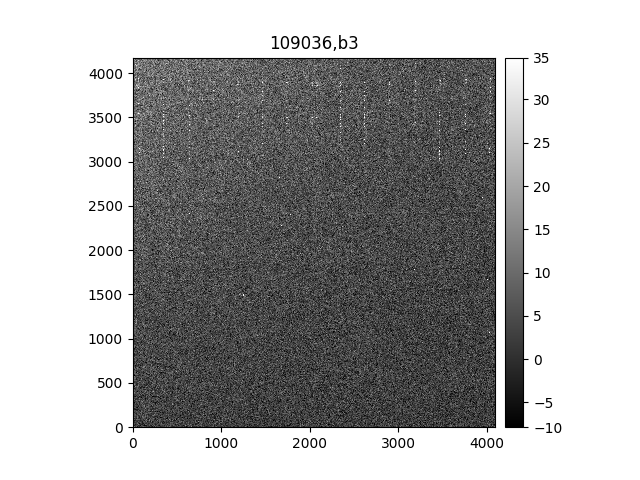

In [10]:
fig = 'calExp'; plt.close(fig); fig = plt.figure(fig)

display = afwDisplay.Display(fig)
#display.scale("asinh", min='zscale')
#display.scale("linear", min=1, max=4, unit='sigma') # unit='percent'
display.scale("linear", min='zscale')
display.mtv(exp, f'{visitId},{arm}{specId}')
addPfsCursor(display, detectorMap=detMap)

### Select Wavelength
Using LAM-selected lines

In [77]:
#rbutler = dafPersist.Butler(f"{dataDir}")
butler.getKeys('raw')
lamps = butler.queryMetadata('raw', ['lamps'], visit=visitId, arm=arm)
print(lamps)

['Kr_eng']


In [78]:
linesConfig = ReadLineListConfig()
linesConfig.minIntensity = 5.0
linesConfig.exclusionRadius = 2.0

In [79]:
lines = ReadLineListTask(config=linesConfig).run(detectorMap=detMap, metadata=exp.getMetadata())
#lines = ReadLineListTask(config=linesConfig).run(detectorMap=detMap, metadata=metadata)

In [12]:
lines.toDataFrame()

,description,wavelength,intensity,status,transition,source
13,NeI,375.52818,500.0,0,UNKNOWN,0
22,NeI,394.46560,20.0,0,UNKNOWN,0
23,NeI,398.51920,20.0,2,UNKNOWN,0
24,NeI,398.53800,70.0,2,UNKNOWN,0
25,NeI,399.64280,10.0,2,UNKNOWN,0
...,...,...,...,...,...,...
569,NeI,641.15186,1500.0,3,UNKNOWN,0
570,NeI,642.34794,1000.0,3,UNKNOWN,0
571,NeI,644.64929,1500.0,1,UNKNOWN,0
572,NeI,650.83255,15000.0,6144,UNKNOWN,0


In [81]:
kr_w=np.array([427.51722, 437.73512, 446.49427, 450.36172, 557.18362, 587.25432, 642.28018, 645.80731])

In [82]:
from pfs.drp.stella.referenceLine import ReferenceLineStatus
status = ReferenceLineStatus.LAM_FOCUS | ReferenceLineStatus.LAM_IMAGEQUALITY  # Selecting both kinds of LAM flags
select = (lines.status & status) != 0  # Bit is set for status flags
select2 = (lines.status == ReferenceLineStatus.GOOD) & (lines.intensity >= 1e4)   # Bit is set for status2 flags (good lines) and bright line
select2 = (lines.intensity >= 2e4)   # Bit is set for status2 flags (good lines) and bright line
select3 = np.isin(lines.wavelength, kr_w)  # For Kr line

In [83]:
dfLines = lines.toDataFrame()
#dfLines = dfLines[dfLines.wavelength.isin(lines[select].wavelength)]
#dfLines = dfLines[dfLines.wavelength.isin(lines[select | select2].wavelength)]
dfLines = dfLines[dfLines.wavelength.isin(lines[select3].wavelength)]

In [84]:
dfLines

,description,wavelength,intensity,status,transition,source
75,KrI,427.51722,1000.0,2,UNKNOWN,0
86,KrI,437.73512,800.0,2,UNKNOWN,0
94,KrI,446.49427,800.0,2,UNKNOWN,0
95,KrI,450.36172,600.0,0,UNKNOWN,0
184,KrI,557.18362,2000.0,2,UNKNOWN,0
232,KrI,587.25432,3000.0,2,UNKNOWN,0
272,KrI,642.28018,100.0,10,UNKNOWN,0
275,KrI,645.80731,200.0,2,UNKNOWN,0


### Search Peak

In [85]:
tmp = list()
# format
columns = ["fiber", "wavelength", "peak", "element", "arm", "X", "Y", "lamp", "description", "status", "source"]

Point = make_dataclass("Point", [("fiber",int), ("wavelength", float), ("peak",int), ("element", str), ("arm", str),\
                                 ("X",float), ("Y",float), ("lamp", str), ("description",str), \
                                 ("status",int), ("source",str)])

for i, lin in enumerate(dfLines.iterrows()):
    for fib in fiberIds:
        info = lin[1]
        wave = info["wavelength"]
        description = info["description"]
        status = info["status"]
        source = info["source"]
        element = description
        lamp = lamps[0]
        x = detMap.findPoint(fib, wave)[0]
        y = detMap.findPoint(fib, wave)[1]
        
        
        tmp.append(Point(fib- 651*(specId-1), wave, i+1, element, arm, x, y, lamp, description, status, source))
        

In [86]:
peaks = pd.DataFrame(data=tmp)

In [16]:
peaks.fiber.unique()

array([  1,  45,  92, 137, 184, 229, 273, 316, 336, 382, 426, 471, 515,
       560, 607, 651])

In [87]:
# Set the wheel size ant exposure time (manually) -- iis: set 1.0
peaks["dcb_wheel"] = 1.0
peaks["exptime"] = 1.0

In [18]:
# Required when lamp is wrong
#peaks["lamp"] = 'Ar'

DCB bundle misconfiguration: orange fibers was included

In [ ]:
peaks = peaks[~peaks['fiber'].isin([12, 60, 110, 161, 210, 259, 341])]

In [20]:
peaks[peaks['fiber']==339]

,fiber,wavelength,peak,element,arm,X,Y,lamp,description,status,source,dcb_wheel,exptime
4,339,696.7352,1,ArI,r,1995.769455,861.966733,Ar,ArI,6146,0,5.7,1.0
14,339,727.4940,2,ArI,r,1996.644996,1212.805645,Ar,ArI,6146,0,5.7,1.0
24,339,763.7208,3,ArI,r,1997.649603,1627.633580,Ar,ArI,6144,0,5.7,1.0
34,339,795.0362,4,ArI,r,1998.503573,1988.033595,Ar,ArI,6144,0,5.7,1.0
44,339,826.6794,5,ArI,r,1999.354850,2354.194151,Ar,ArI,6160,0,5.7,1.0
54,339,912.5471,6,ArI,r,2001.594619,3360.204381,Ar,ArI,6144,0,5.7,1.0
64,339,966.0435,7,ArI,r,2002.891026,3999.517096,Ar,ArI,6144,0,5.7,1.0


### Save peak list (if True)

This list is used to find and measure spots in a set of throughfcus data.

In [88]:
if True:
    # peaks.to_csv("/work/moritani/spsAIT/202311/peaklist/SM2_peakList_ne_b4_20240415_iis.csv")
    peaks.to_csv("/work/moritani/spsAIT/202311/peaklist/SM4_peakList_kr_b4_20240419_iis.csv")

## Image quality

In [2]:
from pfs.lam.opdb import *

In [3]:
import sys

from pfs.lam.imqual2Csv import main as getImqual
from pfs.lam.bestFocusPlanefromCsv import main as getBestFocus


from lsst.daf.butler import Butler

In [4]:
from multiprocessing import Pool, Queue
import time
import os
import numpy as np

### Limit the number of core 
otherwise affect to None

In [5]:
MAX_PROCESS = 30

### Data to be process
to be specified:  arm, specId and visit_set_id (or experimentId)

In [6]:
# specfify the peaklist 
# Copy from ImageQuality_202606.ipynb
d_kr = {'b1': '20240419', 'b2': '20240419', 'b3': '20260305', 'b4': '20240419',
        'n1': '20240822', 'n2': '20250307', 'n3': '20240710', 'n4': '20240724'} 

d_ne = {'b1': '20240415', 'b2': '20240415', 'b3': '20260305', 'b4': '20240415',
        'r1': '20240415', 'r2': '20240415', 'r3': '20260305', 'r4': '20240415',
        'm1': '20251109', 'm2': '20251109', 'm3': '20251109', 'm4': '20251109'}

In [51]:
site = "Subaru"
specId = 3
arm = "r"
fiberType = 'ENGINEERING'

# Ne
experimentId = 64067
peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_ne_{arm}{specId}_{d_ne[f'{arm}{specId}']}_iis.csv"

outpath = "/work/moritani/spsAIT/202606/throughFocus/"

In [21]:
roi_size = 16
seek_size = None
doBck = True

if fiberType == 'ENGINEERING':
    criteria = "EE3"
else:
    criteria = "EE5"
piston_index ="motor1"

cam = f"{arm}{specId}"

### DRP folder

In [10]:
drpPath, repo, rerun = '/work/datastore', 'repo', 'drpActor/reductions/'
datastore = drpPath
collection = [c for c in list(Butler(datastore).registry.queryCollections()) if c.startswith(rerun)]
drpVer='gen3'

### Option to define outputs, plots


In [27]:
roiPlot = True
plotPeaksFlux = True
doFit = False
doLSF = False
doPrint=True

In [15]:
visitStart, visitEnd = getVisitRange_fromWeb(experimentId, url="http://133.40.164.16/sps-logs/index.html")

# Ne
#visitStart, visitEnd = 124705, 124729

# Kr
#visitStart, visitEnd = 124730, 124754

print(visitStart, visitEnd)


144517 144541


In [28]:
def task(i, peaklist=peaklist, cam=cam, rerun=rerun, experimentId=experimentId,
         outpath=outpath, drpPath=drpPath, repo=repo,
         roi_size=roi_size, seek_size=seek_size, doBck=doBck, roiPlot=roiPlot,
         plotPeaksFlux=plotPeaksFlux, doFit=doFit, doLSF=doLSF, doPrint=doPrint,
         fiberType=fiberType, drpVer=drpVer):

    #print(f'run{i}')
    return getImqual(i, peaklist, cam, rerun, experimentId, outpath, drpPath, repo, \
                                roi_size, seek_size, doBck, roiPlot, plotPeaksFlux, doFit, doLSF, doPrint,
                    fiberType=fiberType, drpVer=drpVer)

In [24]:
visitIds = range(visitStart, visitEnd+1)
#visitIds = [124706, 124713, 124714, 124716, 124717, 124718, 124719, 124720, 124722, 124723, 124725]
# Kr: The last one usually fails?
#visitIds = visitIds[:-1]
print(f"{len(visitIds)} visits")

25 visits


In [25]:
MAX_PROCESS = os.cpu_count() if MAX_PROCESS is None else MAX_PROCESS
print(MAX_PROCESS)

30


In [29]:
if __name__ == '__main__':
    pool_size = min(os.cpu_count(), len(visitIds), MAX_PROCESS)
    p = Pool(processes = pool_size)
    start = time.time()
    async_result = p.map_async(task, visitIds,chunksize=10)
    async_result.wait()
    p.close()
    p.join()
    print("Complete")
    end = time.time()
    print('total time (s)= ' + str(end-start))

/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions/roi16/doBckTrue/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions/roi16/doBckTrue/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions/roi16/doBckTrue

Start visit 144527 of r3 with /work/moritani/spsAIT/202311/peaklist/SM3_peakList_ne_r3_20260305_iis.csv

Start visit 144537 of r3 with /work/moritani/spsAIT/202311/peaklist/SM3_peakList_ne_r3_20260305_iis.csv
Start visit 144517 of r3 with /work/moritani/spsAIT/202311/peaklist/SM3_peakList_ne_r3_20260305_iis.csv



drp datastore: /work/datastore
collection from drpActor/reductions/: 373 entries
drp datastore: /work/datastore
collection from drpActor/reductions/: 373 entries
drp datastore: /work/datastore
collection from drpActor/reductions/: 373 entries
Complete
total time (s)= 7.256038665771484


In [ ]:
dataId=dict(arm='r', spectrograph=3, visit=144537)
butler = Butler(datastore, collections=collection, instrument='PFS')
butler.get("postISRCCD", dataId)

### If DRP Actor is not working...

In [32]:
import glob
import astropy.io.fits as fio
from pfs.lam.linePeaksList import filterPeakList
from pfs.lam.analysisPlot import plotRoiPeak, plotPeaksBrightness
from pfs.lam.detAnalysis import *

In [52]:
experimentId = 64067
lamps = ['Ne']
line = 'Ne'
exptime = 60
colldir = '20260504T031724Z'

visitStart, visitEnd = getVisitRange_fromWeb(experimentId, url="http://133.40.164.16/sps-logs/index.html")
visitIds = range(visitStart, visitEnd+1)
for visitId in visitIds:

    imname =f'/data/drp/datastore/drpActor/reductions/{colldir}/postISRCCD/*/{visitId}/postISRCCD_PFS_{visitId}_{cam}_drpActor_reductions_{colldir}.fits'
    #print(imname)
    fname = glob.glob(imname)[0]

    csvPath = os.path.join(outpath,f"sm{specId}",f"Exp{experimentId}",rerun,f"roi{roi_size}",f"doBck{doBck}")

    if not os.path.exists(csvPath):
        os.makedirs(csvPath)


    print(f'Processing {cam}: {visitId}', end='\r')
    if line == 'Kr':
        peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_kr_{cam}_{d_kr[cam]}_iis.csv"
    elif line == 'Ne':
        peaklist = f"/work/moritani/spsAIT/202311/peaklist/SM{specId}_peakList_ne_{cam}_{d_ne[cam]}_iis.csv"

    peaks = filterPeakList(peaklist, arm, lamps) if peaklist is not None else None

    fits = fio.open(fname)

    dataId=dict(arm=arm, spectrograph=specId, visit=visitId)
    imageInfo = dict(dataId)
    imageInfo.update(filename=fname)
    imageInfo.update(experimentId=experimentId)    

    # Image HDU1
    image = fits[1].data

    if roiPlot and (peaklist is not None):
        RoiPlotTitle = f"Peaklist roiPlot {cam.upper()} Exp{experimentId} - visit{visitId} - roi_size={roi_size}\n"
        plotRoiPeak(image, peaks, roi_size=roi_size, savePlotFile=os.path.join(csvPath,f"{cam}_{visitId}_rawPeak"),raw=True,doSave=True, title=RoiPlotTitle )

    
    data = getFullImageQuality(image, peaklist, imageInfo=imageInfo,
                               roi_size=roi_size, EE=[3,5], seek_size=seek_size,
                               com=True, doBck=doBck, doFit=doFit, doLSF=doLSF, doSep=True,fullSep=False,
                               doPlot=roiPlot, doPrint=doPrint,
                               mask_size=20, threshold=50, subpix=5 , maxPeakDist=80,
                               maxPeakFlux=40000, minPeakFlux=2000, calexpMask=None)

    now = datetime.now() # current date and time\n",
    date_time = now.strftime("%Y%m%dT%Hh%M")
    lwh=None

    csvName = f"Imquality_{cam}_Exp{experimentId}_{visitId}_{date_time}.csv"
    if not os.path.exists(csvPath):
        os.makedirs(csvPath,exist_ok =True)
    data.to_csv(os.path.join(csvPath, csvName))
    if roiPlot:
        RoiPlotName = f"roiPlot_{cam}_Exp{experimentId}_{visitId}_{date_time}"
        RoiPlotTitle = f"roiPlot {cam.upper()} Exp{experimentId} - visitId {visitId} - roi_size={roi_size}\n{date_time}"
        plotRoiPeak(image, data, roi_size, savePlotFile=os.path.join(csvPath, RoiPlotName),raw=False,doSave=True, title=RoiPlotTitle)
    if plotPeaksFlux:
        plotPeaksBrightness(data, doSave=True, savePlotFile=os.path.join(csvPath,f"{cam}_{visitId}_fluxes_{'_'.join(lamps)}{exptime:.0f}s_lwh{lwh}"),
                            plot_title=f"{cam}_{visitId} - {'_'.join(lamps)} exptime {exptime}s lwh {lwh}")

## Best Focus 

In [48]:
#experimentId = [53865]  # fpaThroughFocus
experimentId = [64067]  # detectorThroughFocus

In [38]:
filtered_waves = None #[763.7208,912.5471]
#filtered_waves = [642.28018]
#filtered_waves = [970.688]
#filtered_waves = [966.0435]
#filtered_waves = [594.6481, 609.78506, 638.4756, 640.40177]

In [49]:
filtered_fibers = None

In [50]:
filtered_waves = filtered_waves if filtered_waves is None else np.array(filtered_waves)
getBestFocus(experimentId, cam, rerun, criteria, outpath, drpPath, repo, roi_size, doBck, piston_index, filtered_waves, filtered_fibers, fiberType)


2026-06-11T20h17
/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions//roi16/doBckTrue/

/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions//roi16/doBckTrue/Imquality_r3_Exp[64067]*

Wavelength used: [638.4756  693.13787 660.07754 650.83255 717.59154 724.71631 808.46801
 830.26062 846.56824 892.19496 915.11829]
[  1  45  92 137 184 229 273 316 336 382 426 471 515 560 607 651] [638.4756  650.83255 660.07754 693.13787 717.59154 724.71631 808.46801
 830.26062 846.56824 892.19496 915.11829]

 write ThFocus plot png file: /work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions//roi16/doBckTrue/Exp[64067]_thfocus_fit_bounds_070_163_err_max_motor1_2026-06-11T20h17 

Spatial Tip -3.600e-04 rad => -22.1 microns
Spectral Tilt -2.396e-04 rad => -15.0 microns
bestFocus 190.8 microns
2026-06-11 20:22:56.316969 
/work/moritani/spsAIT/202606/throughFocus/sm3/Exp64067/drpActor/reductions//roi16/doBckTrue/
ExpId [64067]
InvMat_sm1_R1_17se

### Check throughFocus plot:
and Use filtered_waves above if needed  and recalculate the best focus

Copy paste the image path from the line <b>write ThFocus plot png file:</b> above (and add .png)

In [34]:
thFocusPlot = "/work/moritani/spsAIT/202410/throughFocus/sm4/Exp39145/drpActor/reductions//roi24/doBckTrue/Exp[39143, 39145]_thfocus_fit_bounds_070_163_err_max_motor1_2024-10-21T05h28.png"

In [35]:
from IPython.display import display, Image

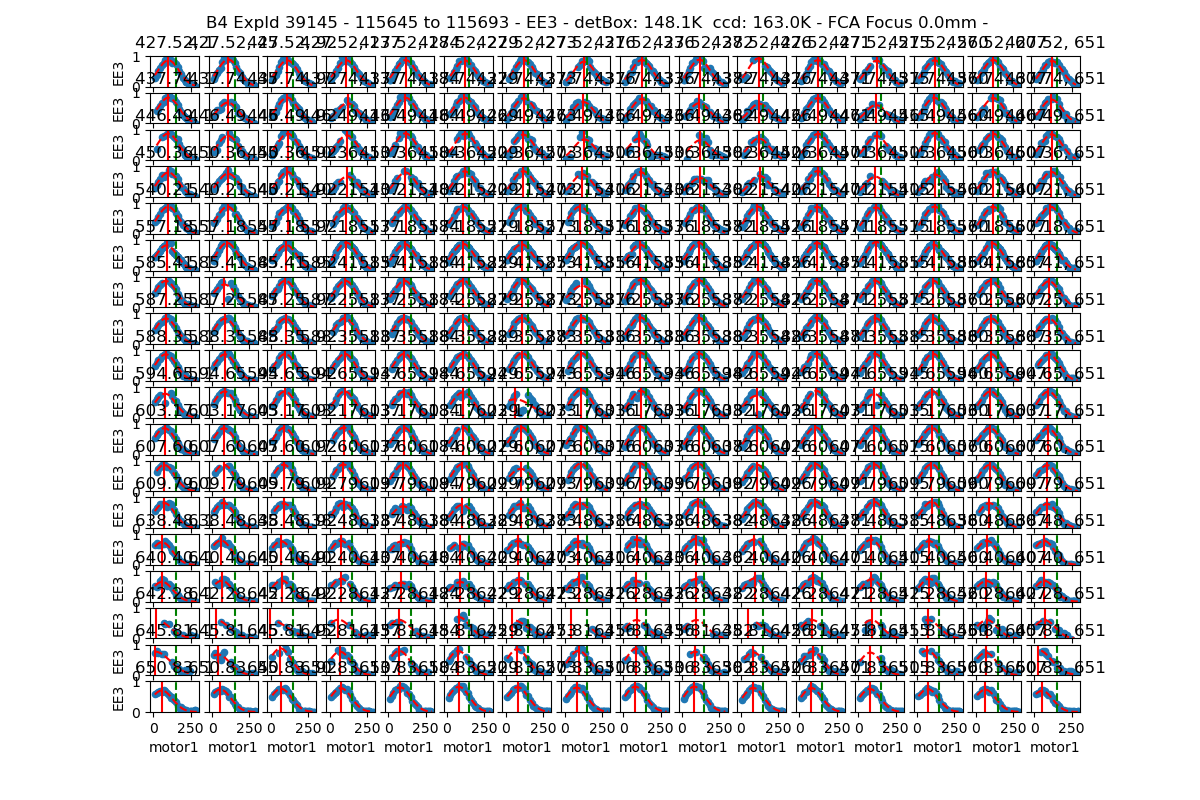

In [36]:
display(Image(thFocusPlot))

Focus in 2025.11

    xcu_r3 motors moveCcd a=213.20 b=204.29 c=203.66 microns abs
    DetBox 156.5 K

Focus in 2026.06

    xcu_r3 motors moveCcd a=195.87 b=182.56 c=182.49 microns abs
    DetBox 144.8 K

(Focusshift: 2.25um/K (@DetBox))

--------------------------

In [ ]:
testPath =  "/work/fmadec/spsAIT/202312/sm2/Exp30017/drpActor/CALIB/roi24/doBckTrue/"